# observation cost

In [56]:

import torch
from utils import mmuot_general_costings
import pwbarycentres as pwb
from pwbarycentres import asymmetric_cost, generate_barycentredataprocessor, asymmetric_sinkhorn_algorithm
from mmuot import symmetric_cost
import pickle
import matplotlib.pyplot as plt
import numpy as np


In [57]:
epsilon = 0.005
rho = 1.0
aprox_type = 'tv'


In [58]:

# load the data
with open('/home/jjf817/PhD_jobs/simple_barycentres/ensemble_data/ensemble_dataset_19.pkl', 'rb') as f:
    dictionary_in_time = pickle.load(f)

times = dictionary_in_time['times']
members = dictionary_in_time['members']
grid = dictionary_in_time['grid']
X = grid

cost_dict_over_time = {}

time_series_debiased_costs = []

t = 20


/tmp/ipykernel_2852198/3404555550.py:27: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]
[0.0005337593506632149, 0.0016012819937819838]


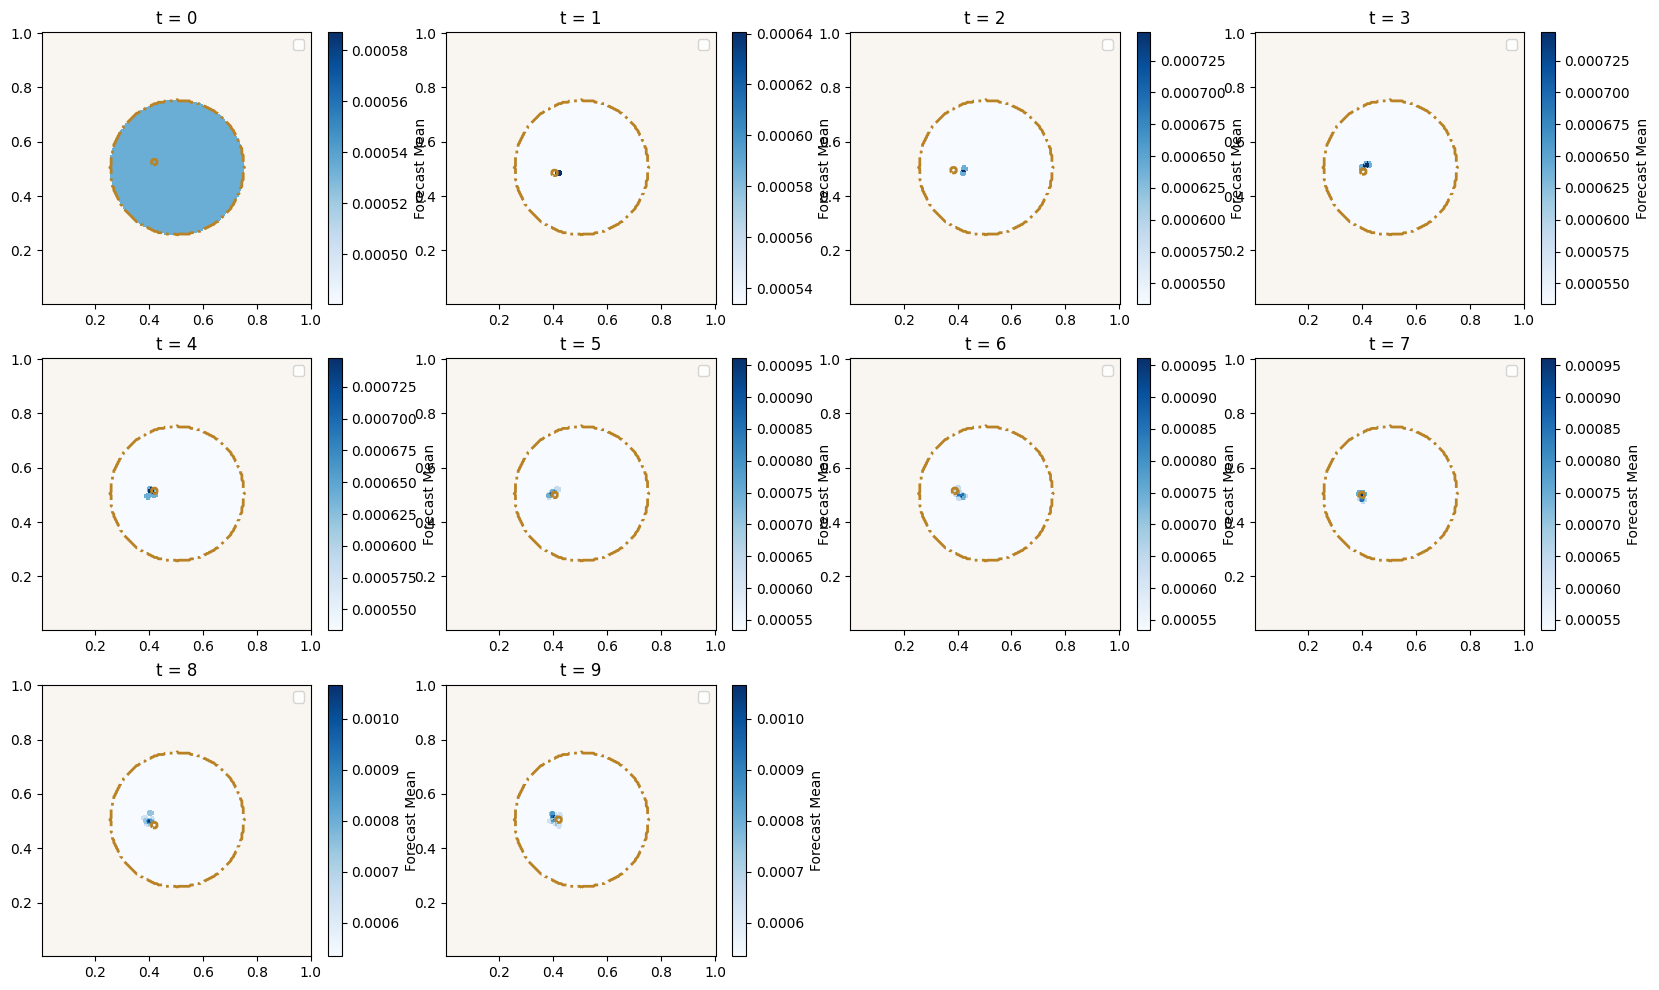

In [59]:
times = dictionary_in_time['times']
M = len(dictionary_in_time['members'])
rows = (len(times)//4 + 1)
cols = 4

fig = plt.figure(figsize=(cols * 5, rows * 4))

for t in times:
    obs = dictionary_in_time[t]['observation']
    forecasts_mean = np.stack([k[0] for k in dictionary_in_time[t]['forecasts']], axis=-1).mean(-1)
    ax = fig.add_subplot(rows, cols, times.index(t)+1)
    ax.set_title(f't = {t}')
    ax.set_facecolor("#f9f6f1")


    im = ax.pcolormesh(
        X[:, :, 0],
        X[:, :, 1],
        np.ma.masked_where(forecasts_mean <= 0, forecasts_mean),
        cmap='Blues',
        shading='auto'
    )
    plt.colorbar(im, ax=ax, label='Forecast Mean')

    mask = obs[0]>0
    print([np.unique(obs[0])[1]-1e-9] if len(np.unique(obs[0])) == 2 else [np.unique(obs[0])[1]-1e-9, np.unique(obs[0])[2]+1e-9])
    ax.contour(
        X[:, :, 0],
        X[:, :, 1],
        obs[0],
        levels=[np.unique(obs[0])[1]-1e-9] if len(np.unique(obs[0])) == 2 else [np.unique(obs[0])[1]-1e-9, np.unique(obs[0])[2]-1e-9],
        # cmap='copper',
        colors="#b98224",
        linestyles='dashdot',
        linewidths=2,
        label='Observation'
    )
    ax.legend(loc='upper right')

# testiong se costs

In [60]:
cuda = 0
data_processor = pwb.generate_barycentredataprocessor(
    dictionary_in_time[t]['forecasts'], 
    barycentre_grid=grid,
    grid=grid, 
    weights=None, 
    cuda_device=f'cuda:{cuda}',
    potentials = 'f'
)

In [61]:
data_processor, barycentre, potential_error_list, barycentre_error_list, constraint_dict = (
            pwb.asymmetric_sinkhorn_log_algorithm(
                data_processor,
                epsilon=epsilon,
                rho=rho,
                aprox=aprox_type,
                max_iterates=100,
                tol=1e-5,
                epsilon_annealing=False,
                debiasing=True,
                verbose=False,
                measure_constraints=True,
                lags={
                    'barycentre': 1,
                    'debiasing': 1,
                }
            )
        )

In [62]:
_, _, se_dict = pwb.asymmetric_cost(
        data_processor,
        epsilon,
        rho,
        aprox=aprox_type,
        debiasing=True,
        verbose=False,
        return_breakdown=True,
    )

In [63]:
se_dict

{'total_cost': 8.705044392140482e-06,
 'unbalanced_sinkhorn_terms': [0.012527458020331506,
  0.012527481453006879,
  0.012527473520800102,
  0.012527466979114499,
  0.012527465953642597,
  0.01252750443267845,
  0.012527473520800102,
  0.01252750646279263,
  0.012527463618302648,
  0.012488904899151427],
 'uot_mu_mu_terms': [0.01276019800120757,
  0.01276023054084288,
  0.012760214153539118,
  0.012760195924755482,
  0.012760200069158931,
  0.0127602441334367,
  0.012760214153539118,
  0.012760221751508089,
  0.01276020181045249,
  0.012673160585110513],
 'debiasing_term': -0.061469953254453265,
 'epsilon': 0.005,
 'rho': 1.0,
 'aprox': 'tv',
 'debiasing': True}

In [64]:
assert 0

AssertionError: 

### testing MUOT symmetric costing and algrothim

In [ ]:
t = 20

In [ ]:
output = symmetric_cost(
    centre=dictionary_in_time[t]['observation'][0], 
    leaf=dictionary_in_time[t]['forecasts'][0][0], 
    grid1=grid,
    grid2=grid,
    no_members=3, 
    epsilon=epsilon, 
    rho=rho, 
    aprox=aprox_type, 
    max_iterates=2000, 
    tol=1e-9,
    cuda_device=cuda)

errs 200000.0 200000.0
errs 663.2268387301898 663.1388483997829
errs 1326.3201161977345 1326.2761071369912
errs 2652.5734326096836 2652.5514211292448
errs 5305.113455273008 inf
errs inf nan
errs nan nan
Converged in 7 iterations with error nan
terms: inf -inf inf 1.6748788868319468e+27


In [ ]:
output

tensor(nan, device='cuda:1', dtype=torch.float64)

In [ ]:
assert 0

AssertionError: 

: 

### calculate cost

In [ ]:

for t in times:
    cost, cost_dict = mmuot_general_costings(
    centre_data=dictionary_in_time[t]['observation'],
    leaf_data=dictionary_in_time[t]['forecasts'],
    epsilon=epsilon, 
    rho=rho, 
    aprox_type=aprox_type, 
    max_iterates=2000, 
    tol=tol, 
    grid=grid, 
    device=f'cuda:{cuda}'
    )

    # calculate full cost
    time_series_debiased_costs.append(
        cost # plus one for centre
    )
    cost_dict_over_time[t] = cost_dict


KeyboardInterrupt: 

In [ ]:
time_series_debiased_costs

[tensor(1.0988e-05, device='cuda:3', dtype=torch.float64),
 tensor(9.4752e-05, device='cuda:3', dtype=torch.float64),
 tensor(0.0002, device='cuda:3', dtype=torch.float64),
 tensor(0.0008, device='cuda:3', dtype=torch.float64),
 tensor(0.0019, device='cuda:3', dtype=torch.float64),
 tensor(0.0037, device='cuda:3', dtype=torch.float64),
 tensor(0.0066, device='cuda:3', dtype=torch.float64),
 tensor(0.0064, device='cuda:3', dtype=torch.float64),
 tensor(0.0073, device='cuda:3', dtype=torch.float64),
 tensor(0.0153, device='cuda:3', dtype=torch.float64)]

### calcaulte asymetric cost


# Forecast Barycentre cost

### barycentre

In [ ]:
import torch
from utils import mmuot_general_costings
import pwbarycentres as pwb
import pickle
import matplotlib.pyplot as plt
import numpy as np


7) DataProcessor generated for barycentre computation
7) DataProcessor generated for barycentre computation
7) DataProcessor generated for barycentre computation
7) DataProcessor generated for barycentre computation
7) DataProcessor generated for barycentre computation


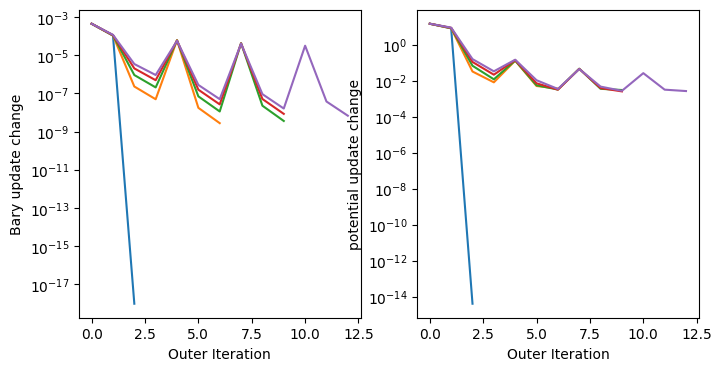

In [ ]:
debiasing = True


bary_list = []
bary_asym_cost_list = []
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for t in times:
    data_bary_list = dictionary_in_time[t]['forecasts']
    # Generate data holding class
    data_processor = pwb.generate_barycentredataprocessor(
        data_bary_list, 
        barycentre_grid=grid,
        grid=grid, 
        weights=None, 
        cuda_device=f'cuda:{cuda}',
        potentials = 'a'
    )

    print("7) DataProcessor generated for barycentre computation")
    data_processor, barycentre, potential_error_list, barycentre_error_list = (
        pwb.asymmetric_sinkhorn_algorithm(
            data_processor,
            epsilon=epsilon,
            rho=rho,
            aprox=aprox_type,
            max_iterates=2000,
            tol=tol,
            epsilon_annealing=False,
            debiasing=debiasing,
            verbose=False,
            debiasing_update_freq=3,
            mass_scaling=False,
        )
    )
    
    bary_list.append(barycentre)

    # cost
    cost, _ = pwb.asymmetric_cost(
        data_processor, 
        epsilon, 
        rho=rho, 
        aprox=aprox_type, 
        debiasing=debiasing
    )
    bary_asym_cost_list.append(cost)

    # convergence checks

    ax[0].semilogy(barycentre_error_list, label=f"{t}")
    ax[0].set_xlabel("Outer Iteration")
    ax[0].set_ylabel("Bary update change")

    ax[1].semilogy(potential_error_list, label=f"{t}")
    ax[1].set_xlabel("Outer Iteration")
    ax[1].set_ylabel("potential update change")
    
plt.show()


In [ ]:
for t in times:
    data_bary_list = dictionary_in_time[t]['forecasts']
    for d in data_bary_list:
        print(d[0].sum())

1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6829463570856686
1.6744061916199628
1.6744061916199626
1.6776087536696025
1.6808113157192421
1.6776087536696025
1.671203629570323
1.6776087536696025
1.6786762743528154
1.6776087536696025
1.6808113157192421
1.6786762743528156
1.675473712303176
1.6829463570856686
1.675473712303176
1.6786762743528159
1.6786762743528159
1.6733386709367495
1.6808113157192424
1.6829463570856684
1.6786762743528156
1.6776087536696023
1.6797437950360288
1.6797437950360288
1.679743795036029
1.6776087536696023
1.6744061916199626
1.6765412329863891
1.6786762743528156
1.6786762743528156
1.6797437950360288
1.681878836402455
1.6797437950360288
1.6776087536696023
1.6733386709367493
1.6776087536696025
1.6797437950360288
1.6733386709367493
1.6786762743528154
1.675473712303176
1.6765412329863891


In [ ]:
for b in bary_list:
    print(torch.sum(b).item())

1.7421307444554892
1.7367126877075898
1.7383314498547726
1.7377854932057573
1.7367041184676006


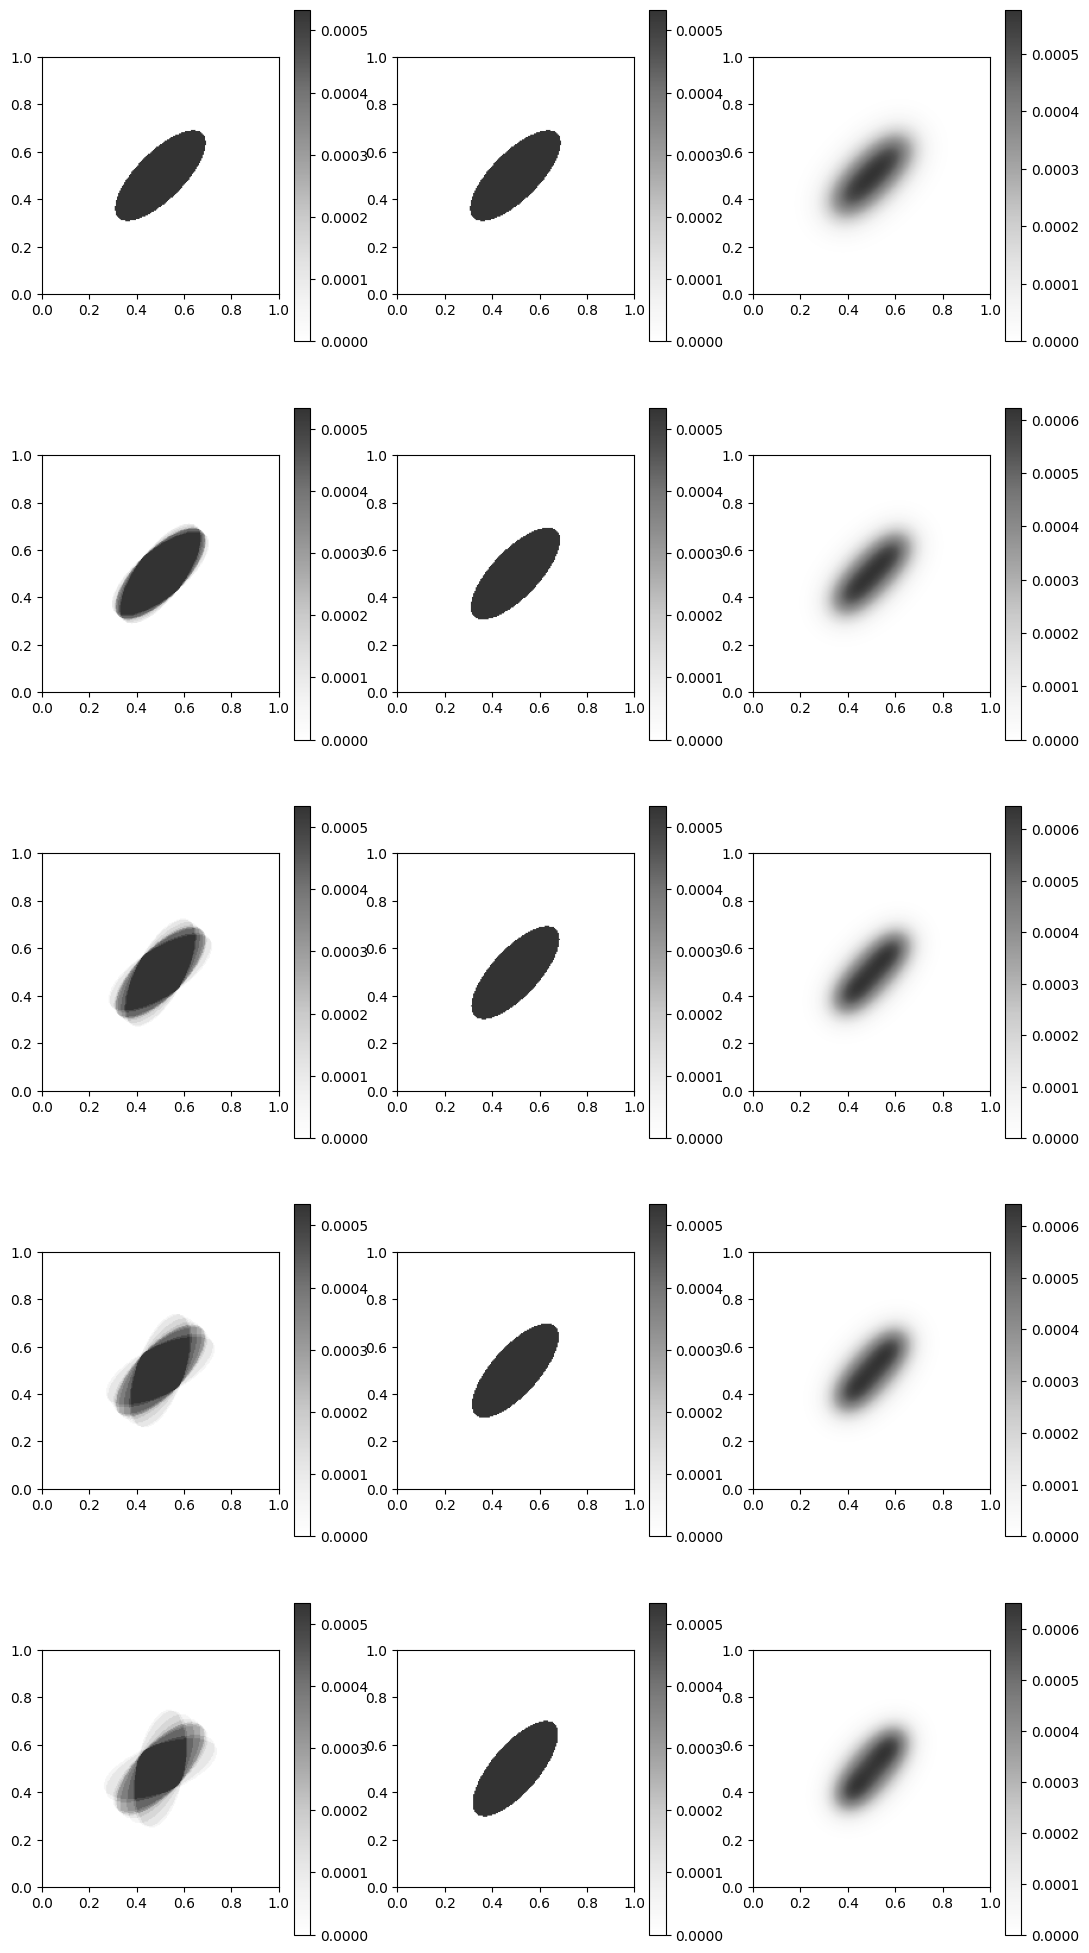

In [ ]:

# save the barycentres
# -------------------------------------------
# PLOTTING:
# -------------------------------------------

# Plot the four density fields
fig, axes = plt.subplots(len(times), 3, figsize=(13, 5*len(times)))

for k, t in enumerate(times):
    ensemble_mean = np.mean(np.stack([f for f,k in dictionary_in_time[t]['forecasts']]), axis=0)

    img = axes[k, 0].imshow(ensemble_mean.reshape(200,  200), extent=[0, 1, 0, 1], origin="lower", cmap="Greys", alpha=0.8)#, norm=LogNorm())
    fig.colorbar(img, ax=axes[k, 0])

    img = axes[k, 1].imshow(dictionary_in_time[t]['observation'][0].reshape(200,  200), extent=[0, 1, 0, 1], origin="lower", cmap="Greys", alpha=0.8)#, norm=LogNorm())
    fig.colorbar(img, ax=axes[k, 1])

    img = axes[k, 2].imshow(bary_list[k].reshape(200,  200).detach().cpu().numpy(), extent=[0, 1, 0, 1], origin="lower", cmap="Greys", alpha=0.8)#, norm=LogNorm())
    fig.colorbar(img, ax=axes[k, 2])

plt.show()


### barycentre mmuot cost

In [ ]:

import torch
from utils import mmuot_general_costings


barycentre_list=bary_list

bary_cost_dict_over_time = {}

bary_time_series_debiased_costs = []

for k, t in enumerate(times):
    cost, cost_dict = mmuot_general_costings(
    centre_data=[barycentre_list[k], None],  # input are in pairs of [density, grid]
    leaf_data=dictionary_in_time[t]['forecasts'],
    epsilon=epsilon, 
    rho=rho, 
    aprox_type=aprox_type, 
    max_iterates=2000,
    tol=tol, 
    grid=grid, 
    device=f'cuda:{cuda}'
    )

    # calculate full cost
    bary_time_series_debiased_costs.append(
        cost # plus one for centre
    )
    bary_cost_dict_over_time[t] = cost_dict


RuntimeError: view size is not compatible with input tensor's size and stride (at least one dimension spans across two contiguous subspaces). Use .reshape(...) instead.

In [ ]:
bary_time_series_debiased_costs

[tensor(0.0033, device='cuda:3', dtype=torch.float64),
 tensor(0.0033, device='cuda:3', dtype=torch.float64),
 tensor(0.0026, device='cuda:3', dtype=torch.float64),
 tensor(0.0029, device='cuda:3', dtype=torch.float64),
 tensor(0.0033, device='cuda:3', dtype=torch.float64),
 tensor(0.0047, device='cuda:3', dtype=torch.float64),
 tensor(0.0063, device='cuda:3', dtype=torch.float64),
 tensor(0.0061, device='cuda:3', dtype=torch.float64),
 tensor(0.0071, device='cuda:3', dtype=torch.float64),
 tensor(0.0110, device='cuda:3', dtype=torch.float64)]

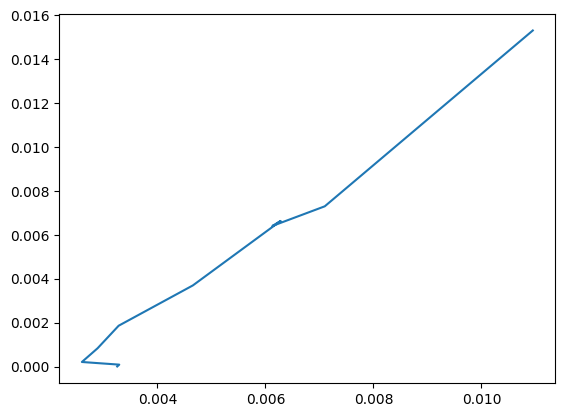

In [ ]:
plt.plot([b.cpu() for b in bary_time_series_debiased_costs], [b.cpu() for b in time_series_debiased_costs])

In [ ]:
bary_cost_dict_over_time

{0: {'bias': tensor(0.0052, device='cuda:3', dtype=torch.float64),
  'bary_time': 0.6057668720000038,
  'debias_0': tensor(0.0089, device='cuda:3', dtype=torch.float64),
  'debias_1': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_2': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_3': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_4': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_5': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_6': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_7': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_8': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_9': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_10': tensor(0.0013, device='cuda:3', dtype=torch.float64),
  'debias_times': array([0.12492222, 0.53942436, 0.52677503, 0.51653546, 0.51873562,
         0.68837442, 0.40448119, 0.50224085, 0.4900738 , 0.52388

### asymmetric cost

cost breakdown: 851316.0493332471 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0494982472 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0497869973 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0509407473 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0526544971 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0555269972 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0594744973 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0591832474 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0603519974 -4256.580246553736 -4256.580246553736
cost breakdown: 851316.0695919974 -4256.580246553736 -4256.580246553736


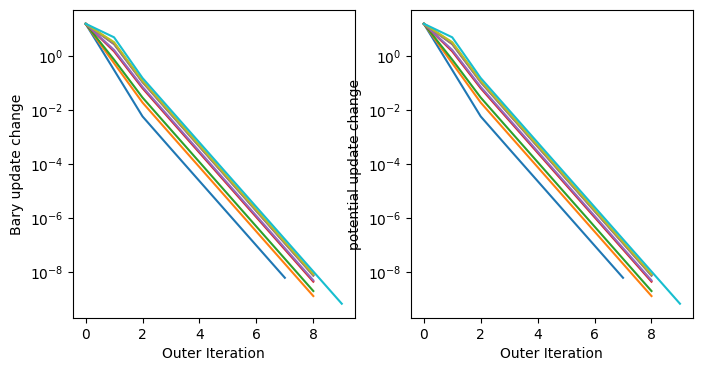

In [ ]:
debiasing = True


obs_list = []
obs_asym_cost_list = []
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for t in times:
    data_bary_list = dictionary_in_time[t]['forecasts']
    observations = dictionary_in_time[t]['observation'][0]
    # Generate data holding class
    data_processor = pwb.generate_barycentredataprocessor(
        data_bary_list, 
        barycentre_grid=grid,
        grid=grid, 
        weights=None, 
        cuda_device=f'cuda:{cuda}',
        potentials = 'a'
    )

    data_processor, barycentre, potential_error_list, barycentre_error_list = (
        pwb.asymmetric_sinkhorn_algorithm(
            data_processor,
            epsilon=epsilon,
            rho=rho,
            aprox=aprox_type,
            max_iterates=2000,
            tol=tol,
            epsilon_annealing=False,
            debiasing=debiasing,
            verbose=False,
            debiasing_update_freq=3,
            mass_scaling=False,
            fixed_barycentre=observations
        )
    )
    assert torch.norm(barycentre.cpu().view(-1) - observations.reshape(-1)) < 1e-9
    # cost
    cost, _ = pwb.asymmetric_cost(
        data_processor, 
        epsilon, 
        rho=rho, 
        aprox=aprox_type, 
        debiasing=debiasing,
        fixed_barycentre=observations

    )
    obs_asym_cost_list.append(cost)

    # convergence checks

    ax[0].semilogy(barycentre_error_list, label=f"{t}")
    ax[0].set_xlabel("Outer Iteration")
    ax[0].set_ylabel("Bary update change")

    ax[1].semilogy(potential_error_list, label=f"{t}")
    ax[1].set_xlabel("Outer Iteration")
    ax[1].set_ylabel("potential update change")
    
plt.show()


In [ ]:
obs_asym_cost_list

[tensor([[842802.8888]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8890]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8893]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8904]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8922]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8950]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8990]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8987]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8999]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.9091]], device='cuda:3', dtype=torch.float64)]

In [ ]:
bary_asym_cost_list

[tensor([[-429815.0678]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.0708]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.0839]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.1176]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.1229]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2022]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2609]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2766]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2950]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.4837]], device='cuda:3', dtype=torch.float64)]

cost breakdown: 851316.0391115512 -4256.5801325855155 -4256.580246553736
cost breakdown: 851316.0391757449 -4256.5801325892935 -4256.580246553736
cost breakdown: 851316.0402385436 -4256.580144637799 -4256.580246553736
cost breakdown: 851316.0407364877 -4256.5801446569885 -4256.580246553736
cost breakdown: 851316.0413813232 -4256.580144685531 -4256.580246553736
cost breakdown: 851316.0434854941 -4256.580144767959 -4256.580246553736
cost breakdown: 851316.0457476315 -4256.58014485708 -4256.580246553736
cost breakdown: 851316.0455438445 -4256.580144843824 -4256.580246553736
cost breakdown: 851316.0468236798 -4256.5801448940365 -4256.580246553736
cost breakdown: 851316.0515411936 -4256.580145038929 -4256.580246553736


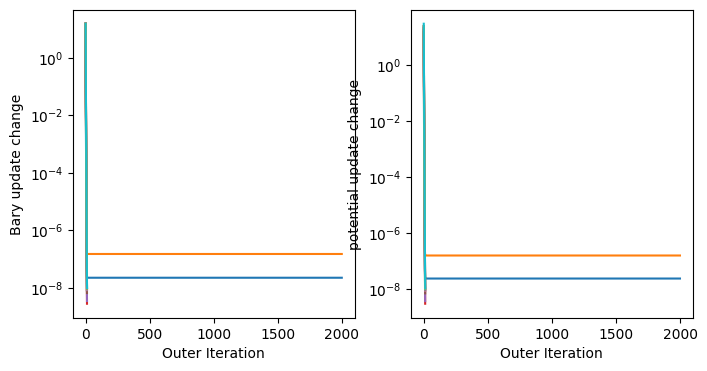

In [ ]:
# test by recalculating costs with the barycentres
debiasing = True


obs_list = []
bary_obs_asym_cost_list = []
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

for t in times:
    data_bary_list = dictionary_in_time[t]['forecasts']
    observations = bary_list[times.index(t)]
    # Generate data holding class
    data_processor = pwb.generate_barycentredataprocessor(
        data_bary_list, 
        barycentre_grid=grid,
        grid=grid, 
        weights=None, 
        cuda_device=f'cuda:{cuda}',
        potentials = 'a'
    )

    data_processor, barycentre, potential_error_list, barycentre_error_list = (
        pwb.asymmetric_sinkhorn_algorithm(
            data_processor,
            epsilon=epsilon,
            rho=rho,
            aprox=aprox_type,
            max_iterates=2000,
            tol=tol,
            epsilon_annealing=False,
            debiasing=debiasing,
            verbose=False,
            debiasing_update_freq=3,
            mass_scaling=False,
            fixed_barycentre=observations
        )
    )
    # cost
    cost, _ = pwb.asymmetric_cost(
        data_processor, 
        epsilon, 
        rho=rho, 
        aprox=aprox_type, 
        debiasing=debiasing,
        fixed_barycentre=observations

    )
    bary_obs_asym_cost_list.append(cost)

    # convergence checks

    ax[0].semilogy(barycentre_error_list, label=f"{t}")
    ax[0].set_xlabel("Outer Iteration")
    ax[0].set_ylabel("Bary update change")

    ax[1].semilogy(potential_error_list, label=f"{t}")
    ax[1].set_xlabel("Outer Iteration")
    ax[1].set_ylabel("potential update change")
    
plt.show()



In [ ]:
obs_asym_cost_list

[tensor([[842802.8888]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8890]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8893]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8904]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8922]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8950]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8990]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8987]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8999]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.9091]], device='cuda:3', dtype=torch.float64)]

In [ ]:
bary_obs_asym_cost_list

[tensor([[842802.8787]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8788]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8798]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8803]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8810]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8831]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8854]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8852]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8864]], device='cuda:3', dtype=torch.float64),
 tensor([[842802.8911]], device='cuda:3', dtype=torch.float64)]

In [ ]:
bary_asym_cost_list

[tensor([[-429815.0678]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.0708]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.0839]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.1176]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.1229]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2022]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2609]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2766]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.2950]], device='cuda:3', dtype=torch.float64),
 tensor([[-429815.4837]], device='cuda:3', dtype=torch.float64)]